#NAME- PAWAN KUSHWAH
#ROLL NO- SA218
# Project Title: Sleep, Screen Time and Stress Analysis

# Problem Statement
I am analyzing sleep patterns, screen time, and stress levels to understand how daily habits affect mental health and fatigue. The goal is to identify which factors contribute most to increased stress.

The dataset used is "Sleep, Screen Time and Stress Analysis" obtained from Kaggle. It contains around 15000 rows and multiple columns such as age, gender, sleep_duration, daily_screen_time, stress_level, and mental_fatigue_score.

Each column represents lifestyle or behavioral factors that may influence stress and overall well-being.

# Dataset Description
The dataset includes the following columns:

- user_id: unique identifier for each user  
- age: age of the individual  
- gender: gender of the user  
- occupation: job or profession of the individual  
- daily_screen_time_hours: average daily screen usage in hours  
- phone_usage_before_sleep_minutes: phone usage before sleep in minutes  
- sleep_duration_hours: total hours of sleep per day  
- sleep_quality_score: quality of sleep on a scale  
- stress_level: level of stress experienced by the individual  
- caffeine_intake_cups: number of caffeine cups consumed per day  
- physical_activity_minutes: time spent on physical activity in minutes  
- notifications_received_per_day: number of notifications received daily  
- mental_fatigue_score: level of mental fatigue of the individual  

These columns represent lifestyle and behavioral factors that may influence stress and overall mental health.

In [1]:
#IMPORTING  ALL LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("sleep_mobile_stress_dataset_15000.csv")

df.head()


,user_id,age,gender,occupation,daily_screen_time_hours,phone_usage_before_sleep_minutes,sleep_duration_hours,sleep_quality_score,stress_level,caffeine_intake_cups,physical_activity_minutes,notifications_received_per_day,mental_fatigue_score
0,1,56,Female,Designer,3.26,86,5.31,7.72,3.49,0,35,119,3.57
1,2,46,Female,Teacher,1.85,32,7.36,9.70,3.01,0,16,299,1.91
2,3,32,Female,Designer,3.04,107,4.50,6.38,5.03,0,17,21,6.05
3,4,25,Male,Software Engineer,9.00,36,6.68,5.53,10.00,0,3,220,9.92
4,5,38,Female,Teacher,3.52,56,7.57,6.69,6.71,4,92,167,5.99


In [6]:
df.shape

(15000, 13)

In [7]:
df.dtypes

,0
user_id,int64
age,int64
gender,object
occupation,object
daily_screen_time_hours,float64
phone_usage_before_sleep_minutes,int64
sleep_duration_hours,float64
sleep_quality_score,float64
stress_level,float64
caffeine_intake_cups,int64


# MARKDOWN
The dataset was loaded successfully. The first 5 rows were displayed, and the shape and data types were checked to understand the structure of the dataset.

In [8]:
df.isnull().sum()

,0
user_id,0
age,0
gender,0
occupation,0
daily_screen_time_hours,0
phone_usage_before_sleep_minutes,0
sleep_duration_hours,0
sleep_quality_score,0
stress_level,0
caffeine_intake_cups,0


# MARKDOWN
No missing values were found in the dataset, as all columns contain zero null values. Therefore, no data imputation or removal was required.

# Remove duplicate rows if any

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df = df.drop_duplicates()

# MARKDOWN
No duplicate rows were found in the dataset, so no rows were removed.

# SLEEP DURATION

In [12]:
# Sleep Duration
print("Sleep Duration Stats:")
print("Mean:", df['sleep_duration_hours'].mean())
print("Median:", df['sleep_duration_hours'].median())
print("Mode:", df['sleep_duration_hours'].mode()[0])
print("Std Dev:", df['sleep_duration_hours'].std())
print("Variance:", df['sleep_duration_hours'].var())
print("Range:", df['sleep_duration_hours'].max() - df['sleep_duration_hours'].min())
print("Mid-range:", (df['sleep_duration_hours'].max() + df['sleep_duration_hours'].min()) / 2)

Sleep Duration Stats:
Mean: 6.509683333333333
Median: 6.49
Mode: 8.09
Std Dev: 1.4526889710941742
Variance: 2.1103052467386503
Range: 5.0
Mid-range: 6.5


# STRESS LEVEL

In [13]:
# Stress Level
print("\nStress Level Stats:")
print("Mean:", df['stress_level'].mean())
print("Median:", df['stress_level'].median())
print("Mode:", df['stress_level'].mode()[0])
print("Std Dev:", df['stress_level'].std())
print("Variance:", df['stress_level'].var())
print("Range:", df['stress_level'].max() - df['stress_level'].min())
print("Mid-range:", (df['stress_level'].max() + df['stress_level'].min()) / 2)


Stress Level Stats:
Mean: 6.980246666666666
Median: 7.38
Mode: 10.0
Std Dev: 2.749382478440498
Variance: 7.559104012755617
Range: 9.0
Mid-range: 5.5


# MARKDOWN
The dataset was checked for missing values and duplicate rows. No missing values or duplicates were found, indicating that the dataset is clean and well-structured.

Statistical measures such as mean, median, mode, standard deviation, variance, range, and mid-range were calculated for sleep duration and stress level to understand their distribution and variability.

# Histogram (Stress Level)

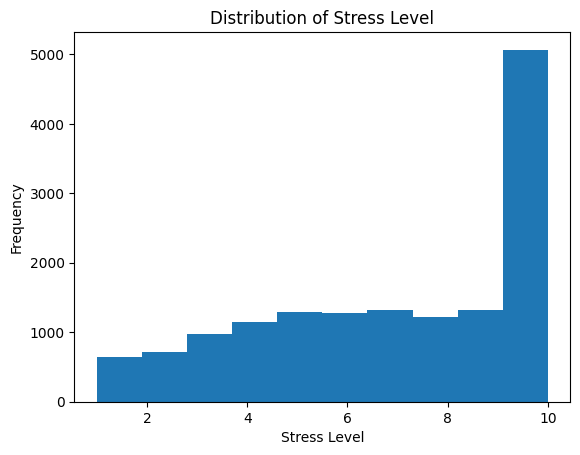

In [14]:
plt.hist(df['stress_level'])
plt.title("Distribution of Stress Level")
plt.xlabel("Stress Level")
plt.ylabel("Frequency")
plt.show()

# MARKDOWN
Most individuals have higher stress levels, as the majority of values are concentrated towards the upper range of the scale.

# Countplot (Gender)

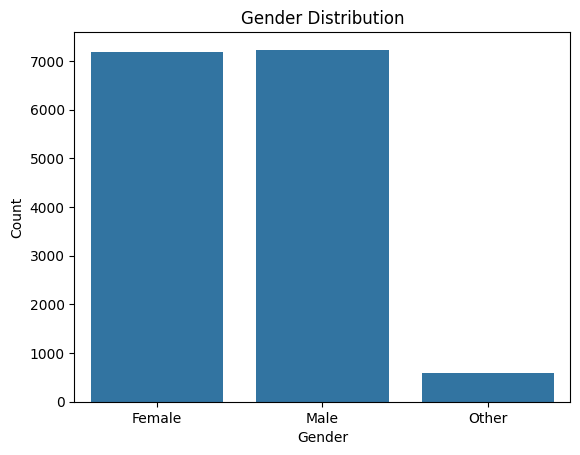

In [15]:
sns.countplot(x='gender', data=df)
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

#MARKDOWN
The dataset shows an almost equal distribution of male and female individuals, with a very small proportion categorized as others.

# Boxplot (Mental Fatigue)

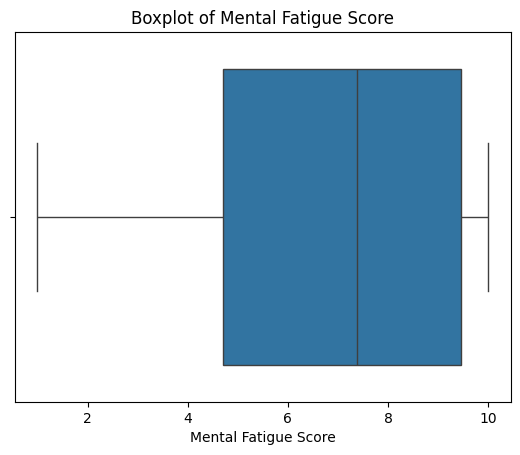

In [16]:
sns.boxplot(x=df['mental_fatigue_score'])
plt.title("Boxplot of Mental Fatigue Score")
plt.xlabel("Mental Fatigue Score")
plt.show()

# MARKDOWN
The boxplot shows that mental fatigue scores are widely spread, with no extreme outliers, indicating consistent variation among individuals.

# Heatmap (correlation)

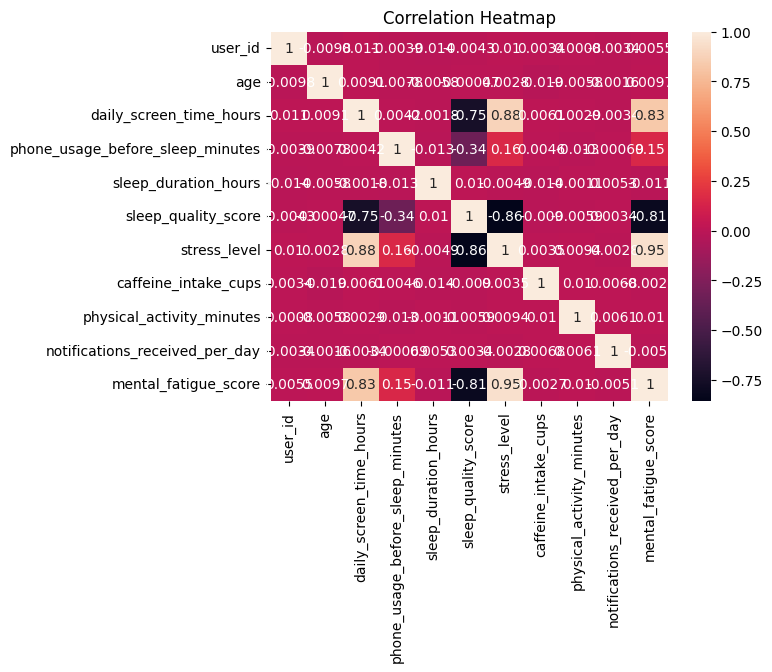

In [18]:
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

# MARKDOWN
The heatmap shows that stress level is strongly positively correlated with mental fatigue and screen time, while sleep quality has a negative relationship with stress.

# SIMPLE Prediction

# MARKDOWN
No encoding was required as only numerical columns were used for prediction.

# Split data into train and test sets (80:20)

In [19]:
from sklearn.model_selection import train_test_split

X = df[['sleep_duration_hours','daily_screen_time_hours','mental_fatigue_score']]
y = df['stress_level']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# MARKDOWN
The dataset was split into training and testing sets using an 80:20 ratio. This means 80% of the data is used to train the model, and 20% is used to test its performance.

This helps evaluate how well the model performs on new, unseen data.

# MODEL

In [20]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

accuracy = model.score(X_test, y_test)
accuracy

0.9268695117121206

# MARKDOWN
The model was trained to predict stress levels based on sleep duration, screen time, and mental fatigue.

The accuracy score shows how well the model performs on unseen data. A higher score indicates better prediction.

# FINDINGS
Finding 1: The histogram shows that most individuals have higher stress levels, indicating that stress is common among people.

Finding 2: The countplot shows a balanced distribution of gender, meaning the dataset represents different groups fairly.

Finding 3: The boxplot shows that mental fatigue scores are widely spread, indicating variation in fatigue levels among individuals.

Finding 4: The heatmap shows a strong positive correlation between mental fatigue and stress level, meaning that higher fatigue is associated with higher stress.

# Recommendations
1. People should reduce their screen time and take regular breaks to lower stress and mental fatigue.

2. Maintaining good sleep habits can help reduce stress and improve overall mental well-being.